In [1]:
from utils import load_player, f_w_v, exe_player, plot_exp,means_exp,plot_evolution, plot_interval_widths_by_player
import pandas as pd
import numpy as np

df=pd.read_excel('./datasets/global_data_7_july_2023_16_may_2025.xlsx')

c:\Users\tdupuy\Documents\Thèse\Online_CP\OCP_relevance_special_issue\utils.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


##### Optimisation $l_r$ and $q_0$

In [ ]:
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])

name_methods = ["PID_log_full_smooth","PID_log_half_smooth","PID_log_half_smooth_bis"] 
l_rs=[8,4,2,1,0.5,0.1,0.05,0.01,0.005,0.001]
q_1=range(0,21)
test_v=range(1,21)

player='MHSC-08'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods,[])
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
best_results = {}

for method in name_methods:
    best_mean_width = float("inf")
    best_result = None
    best_params = None
    best_stats = None
    for l_r in l_rs:
        for q in q_1:
            #print(f'l_r={l_r}; q_0={q}')
            for v in test_v:
                result = exe_player(
                    df_player,
                    player,
                    start_train,
                    end_train,
                    start_test,
                    end_test,
                    basemodel,
                    method,
                    alpha,
                    cv_search,
                    cv_method,
                    n_iter_search,
                    with_acute_load,
                    retrain_every_n_steps,
                    sliding=sliding,
                    t_burnin=30,
                    q1=q,
                    lr=l_r,
                    Csat=5,
                    KI=10,
                    f=f_w_v(w, np.array([v]), alpha)
                )
                results[(method, l_r, q)] = result
                cov, mean_width, median_width = means_exp(result)
                #print(cov, mean_width, median_width)
                if round(cov, 2) >= 0.89:
                    if mean_width < best_mean_width:
                        best_mean_width = mean_width
                        best_result = result
                        best_params = (l_r, q, v)
                        best_stats = (cov, mean_width, median_width)
    best_results[method] = {
        "result": best_result,
        "l_r": best_params[0],
        "q_0": best_params[1],
        "v": best_params[2],
        "cov": best_stats[0],
        "mean_width": best_stats[1],
        "median_width": best_stats[2],
    }
for method, info in best_results.items():
    print(f"\nMethod: {method}")
    print(f"Best l_r   : {info['l_r']}")
    print(f"Best q_0   : {info['q_0']}")
    if method in ["PID_log_half_smooth","PID_log_half_smooth_bis","PID_log_full_smooth"]:
        print(f"Best v   : {info['v']}")
    print(f"Coverage   : {info['cov']}")
    print(f"Mean width : {info['mean_width']}")
    print(f"Median wid.: {info['median_width']}")
# method_to_title={"PID_log":"PID","PID_log_half_smooth_bis":"r-aPID","PID_log_half_smooth":'PID Equation (9)',"PID_log_full_smooth":"PID Equation (8)"}
# title=f'exp1_{dataset}_{player}_{basemodel}'
# title_interval=f'exp1_{dataset}_{player}_{basemodel}_interval_evolution'
# plot_evolution(results["PID_log_half_smooth_bis"],title_interval)
# plot_exp(title,results,name_methods,method_to_title)

c:\Users\tdupuy\Documents\Thèse\Online_CP\OCP_relevance_special_issue\utils.py:295: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))



Method: PID_log_full_smooth
Best l_r   : 2
Best q_0   : 8
Best v   : 14
Coverage   : 0.8850574712643678
Mean width : 21.55187660002206
Median wid.: 21.723041116140394

Method: PID_log_half_smooth
Best l_r   : 2
Best q_0   : 8
Best v   : 10
Coverage   : 0.8850574712643678
Mean width : 21.210067489980656
Median wid.: 21.418903683766473

Method: PID_log_half_smooth_bis
Best l_r   : 2
Best q_0   : 8
Best v   : 8
Coverage   : 0.8850574712643678
Mean width : 20.885814289177613
Median wid.: 20.657895630658572


##### MHSC-45

0.8905109489051095 17.398470511016107 16.918792932621443
0.8905109489051095 16.659782245319448 16.492037514864194
0.8868613138686131 18.248870967779837 17.57904330269065
0.8868613138686131 17.490798522981606 17.277814203770873
Figure saved


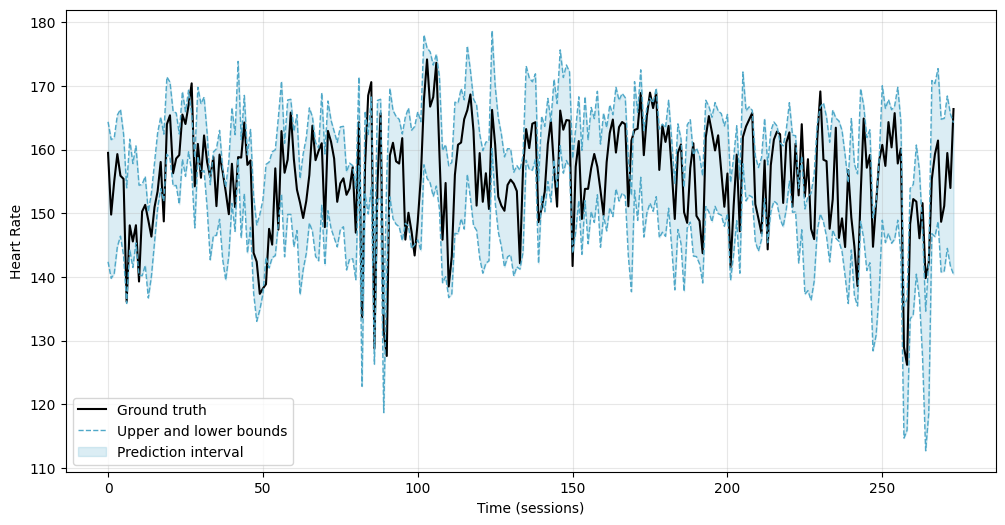

Figure saved


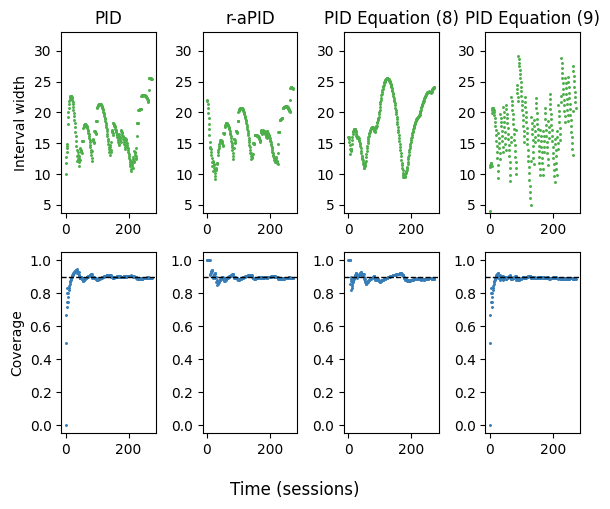

In [ ]:
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])


method_params = {"PID_log":{"l_r":1,"q":5,"v":None},"PID_log_half_smooth_bis":{"l_r":1,"q":11,"v":np.array([6])},
                 "PID_log_full_smooth":{"l_r":0.05,"q":8,"v":np.array([18])},"PID_log_half_smooth":{"l_r":4,"q":2,"v":np.array([20])}}
name_methods=list(method_params.keys())

rows=[]
method_to_title={"PID_log":"PID","PID_log_half_smooth_bis":"r-aPID","PID_log_half_smooth":'PID Equation (9)',"PID_log_full_smooth":"PID Equation (8)"}

player='MHSC-45'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search,cv_method,n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,t_burnin=30,q1=params["q"],lr=params["l_r"],Csat=5,KI=10,f=f_w_v(w,params["v"],alpha))
    results[method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[method],"width_mean":mean_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width})
    print(cov,mean_width,median_width)

title=f'exp1_{dataset}_{player}_{basemodel}'
title_interval=f'exp1_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["PID_log_half_smooth_bis"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-22

0.8953846153846153 23.52355202032442 23.198077583268798
0.8892307692307693 22.634768395241426 22.268180098718403
0.8861538461538462 23.959148309706013 23.494243372239964
0.8861538461538462 23.060443064425133 22.504451949611507
Figure saved


c:\Users\tdupuy\Documents\Thèse\Online_CP\OCP_relevance_special_issue\utils.py:295: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


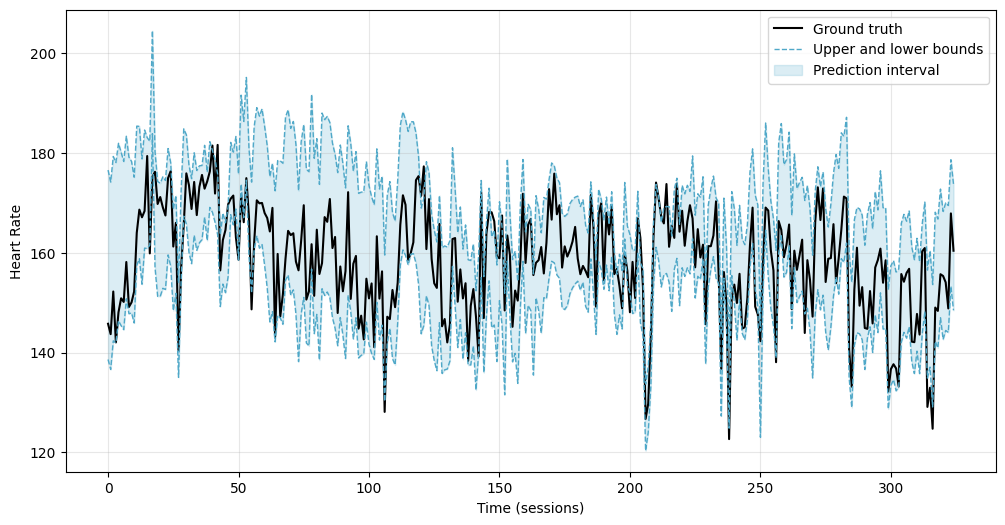

Figure saved


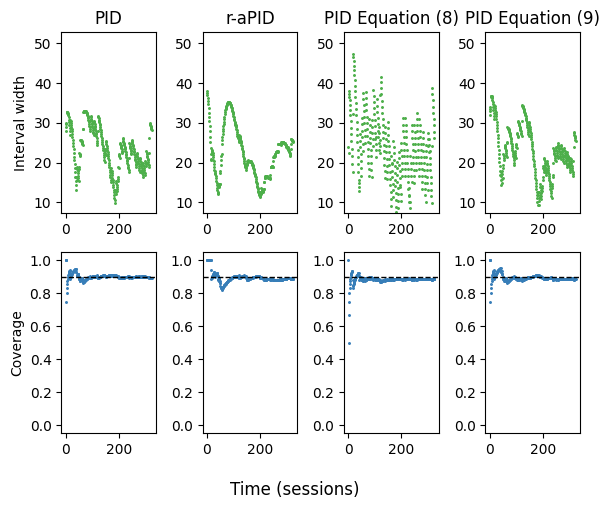

In [ ]:
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])

method_params = {"PID_log":{"l_r":2,"q":15,"v":None},"PID_log_half_smooth_bis":{"l_r":2,"q":19,"v":np.array([2])},
                 "PID_log_full_smooth":{"l_r":8,"q":12,"v":np.array([20])},"PID_log_half_smooth":{"l_r":2,"q":17,"v":np.array([20])}}
name_methods=list(method_params.keys())
method_to_title={"PID_log":"PID","PID_log_half_smooth_bis":"r-aPID","PID_log_half_smooth":'PID Equation (9)',"PID_log_full_smooth":"PID Equation (8)"}

player='MHSC-22'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search,cv_method,n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,t_burnin=30,q1=params["q"],lr=params["l_r"],Csat=5,KI=10,f=f_w_v(w,params['v'],alpha))
    results[method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[method],"width_mean":mean_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width})
    print(cov,mean_width,median_width)

title=f'exp1_{dataset}_{player}_{basemodel}'
title_interval=f'exp1_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["PID_log_half_smooth_bis"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-08

0.8850574712643678 20.691292534812238 20.242617601529844
0.8850574712643678 20.885814289177613 20.657895630658572
0.8850574712643678 21.55187660002206 21.723041116140394
0.8850574712643678 21.210067489980656 21.418903683766473
Figure saved


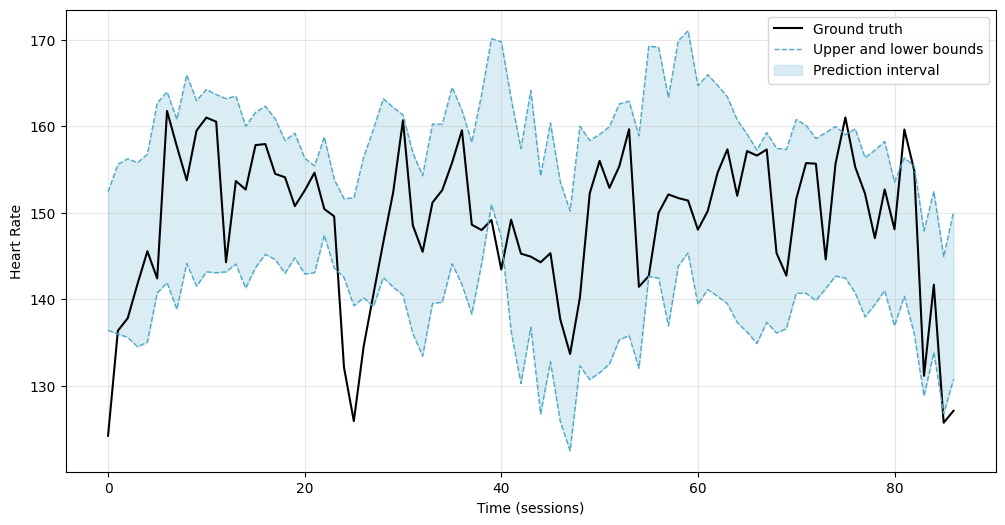

Figure saved


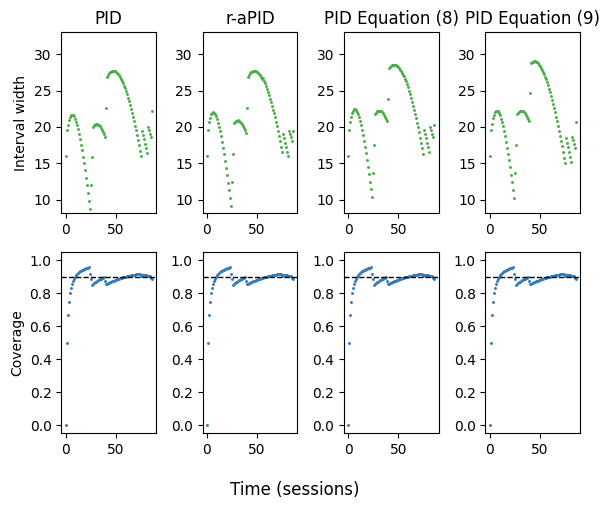

In [ ]:
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])

method_params = {"PID_log":{"l_r":2,"q":8,"v":None},"PID_log_half_smooth_bis":{"l_r":2,"q":8,"v":np.array([8])},
                 "PID_log_full_smooth":{"l_r":2,"q":8,"v":np.array([14])},"PID_log_half_smooth":{"l_r":2,"q":8,"v":np.array([10])}}
name_methods=list(method_params.keys())
method_to_title={"PID_log":"PID","PID_log_half_smooth_bis":"r-aPID","PID_log_half_smooth":'PID Equation (9)',"PID_log_full_smooth":"PID Equation (8)"}

player='MHSC-08'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search,cv_method,n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,t_burnin=30,q1=params["q"],lr=params["l_r"],Csat=5,KI=10,f=f_w_v(w,params['v'],alpha))
    results[method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[method],"width_mean":mean_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width})
    print(cov,mean_width,median_width)
title=f'exp1_{dataset}_{player}_{basemodel}'
title_interval=f'exp1_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["PID_log_half_smooth_bis"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-10

0.896 18.110925986745613 17.965333531042404
0.888 17.213615269541247 16.57979836489551
0.888 17.269606280244343 17.388685790250236
0.888 17.65721089032688 17.75548118141387
Figure saved


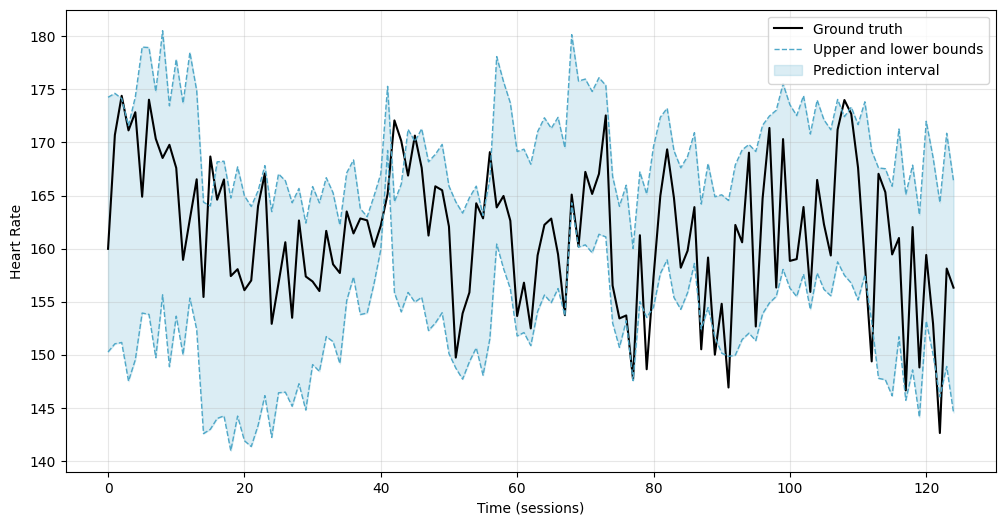

Figure saved


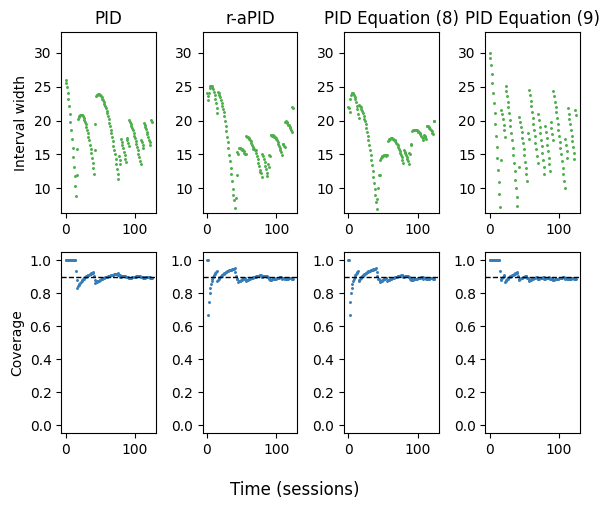

In [ ]:
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])

method_params = {"PID_log":{"l_r":2,"q":13,"v":None},"PID_log_half_smooth_bis":{"l_r":2,"q":12,"v":np.array([5])},
                 "PID_log_full_smooth":{"l_r":1,"q":11,"v":np.array([17])},"PID_log_half_smooth":{"l_r":4,"q":15,"v":np.array([12])}}
name_methods=list(method_params.keys())
method_to_title={"PID_log":"PID","PID_log_half_smooth_bis":"r-aPID","PID_log_half_smooth":'PID Equation (9)',"PID_log_full_smooth":"PID Equation (8)"}

player='MHSC-10'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search,cv_method,n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,t_burnin=30,q1=params["q"],lr=params["l_r"],Csat=5,KI=10,f=f_w_v(w,params['v'],alpha))
    results[method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[method],"width_mean":mean_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width})
    print(cov,mean_width,median_width)
title=f'exp1_{dataset}_{player}_{basemodel}'
title_interval=f'exp1_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["PID_log_half_smooth_bis"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-07

0.8975741239892183 19.545317118199215 19.21567188948245
0.8975741239892183 19.267314225417543 19.579429227753394
0.8867924528301887 18.88507009878206 18.740530724628286
0.8867924528301887 18.357381602286356 18.738868218986966
Figure saved


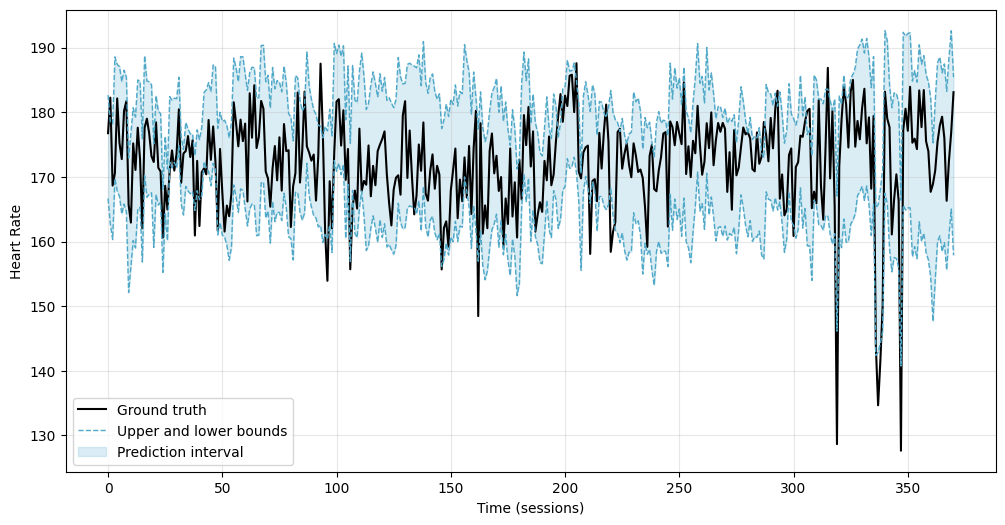

Figure saved


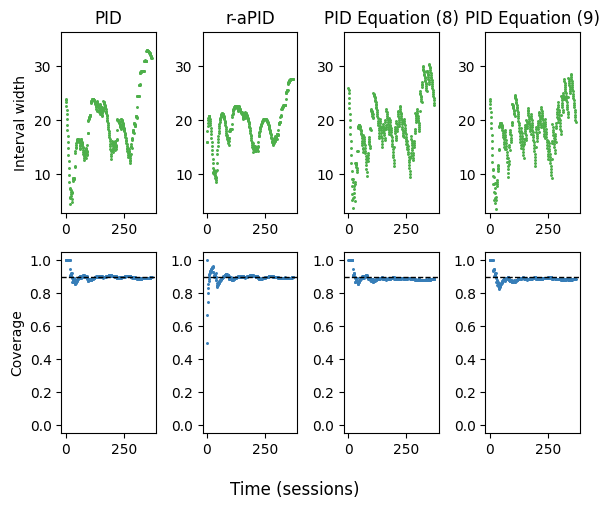

In [ ]:
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])

method_params = {"PID_log":{"l_r":1,"q":12,"v":None},"PID_log_half_smooth_bis":{"l_r":0.5,"q":8,"v":np.array([17])},
                 "PID_log_full_smooth":{"l_r":2,"q":13,"v":np.array([19])},"PID_log_half_smooth":{"l_r":2,"q":12,"v":np.array([14])}}
name_methods=list(method_params.keys())
method_to_title={"PID_log":"PID","PID_log_half_smooth_bis":"r-aPID","PID_log_half_smooth":'PID Equation (9)',"PID_log_full_smooth":"PID Equation (8)"}

player='MHSC-07'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search,cv_method,n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,t_burnin=30,q1=params["q"],lr=params["l_r"],Csat=5,KI=10,f=f_w_v(w,params['v'],alpha))
    results[method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[method],"width_mean":mean_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width})
    print(cov,mean_width,median_width)
title=f'exp1_{dataset}_{player}_{basemodel}'
title_interval=f'exp1_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["PID_log_half_smooth_bis"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-32

0.9024390243902439 17.628701371089075 16.870427060605664
0.8861788617886179 17.352566621070103 15.898549739122245
0.8861788617886179 17.60920619789738 16.18725308209696
0.8943089430894309 16.6682374515759 16.820515658801128
Figure saved


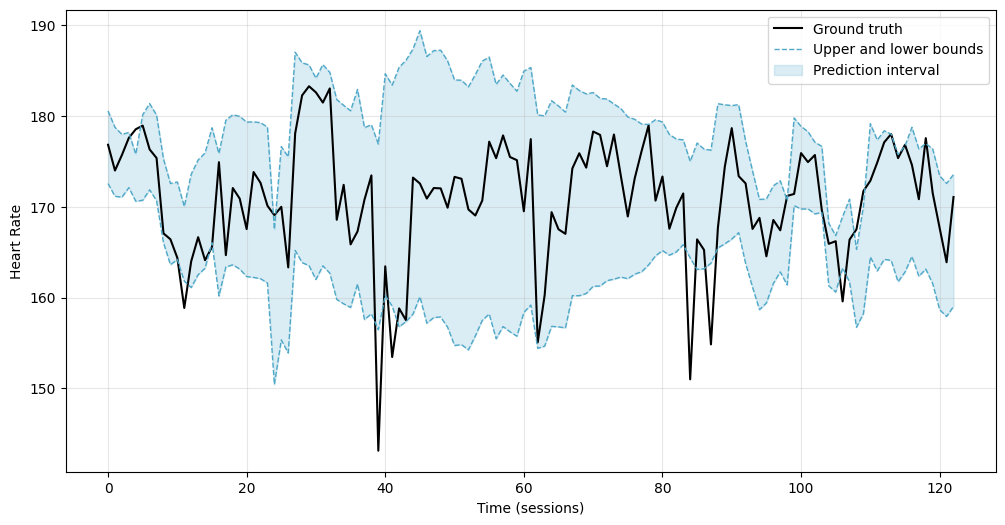

Figure saved


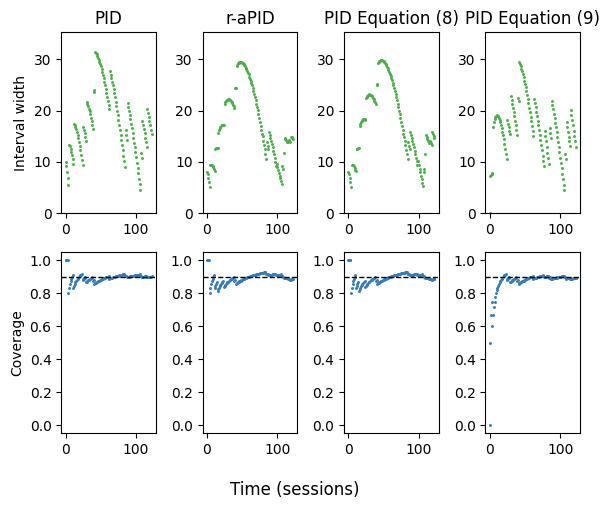

In [ ]:
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])

method_params = {"PID_log":{"l_r":4,"q":5,"v":None},"PID_log_half_smooth_bis":{"l_r":2,"q":4,"v":np.array([10])},
                 "PID_log_full_smooth":{"l_r":2,"q":4,"v":np.array([18])},"PID_log_half_smooth":{"l_r":4,"q":0,"v":np.array([6])}}
name_methods=list(method_params.keys())
method_to_title={"PID_log":"PID","PID_log_half_smooth_bis":"r-aPID","PID_log_half_smooth":'PID Equation (9)',"PID_log_full_smooth":"PID Equation (8)"}

player='MHSC-32'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search,cv_method,n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,t_burnin=30,q1=params["q"],lr=params["l_r"],Csat=5,KI=10,f=f_w_v(w,params['v'],alpha))
    results[method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[method],"width_mean":mean_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width})
    print(cov,mean_width,median_width)
title=f'exp1_{dataset}_{player}_{basemodel}'
title_interval=f'exp1_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["PID_log_half_smooth_bis"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-18

0.8986486486486487 20.245097372750884 20.487054411903813
0.8885135135135135 19.37728616381432 19.72808299883505
0.8851351351351351 19.824083303957448 20.884368083189173
0.8851351351351351 19.4614274710322 19.97369321887507
Figure saved


c:\Users\tdupuy\Documents\Thèse\Online_CP\OCP_relevance_special_issue\utils.py:295: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


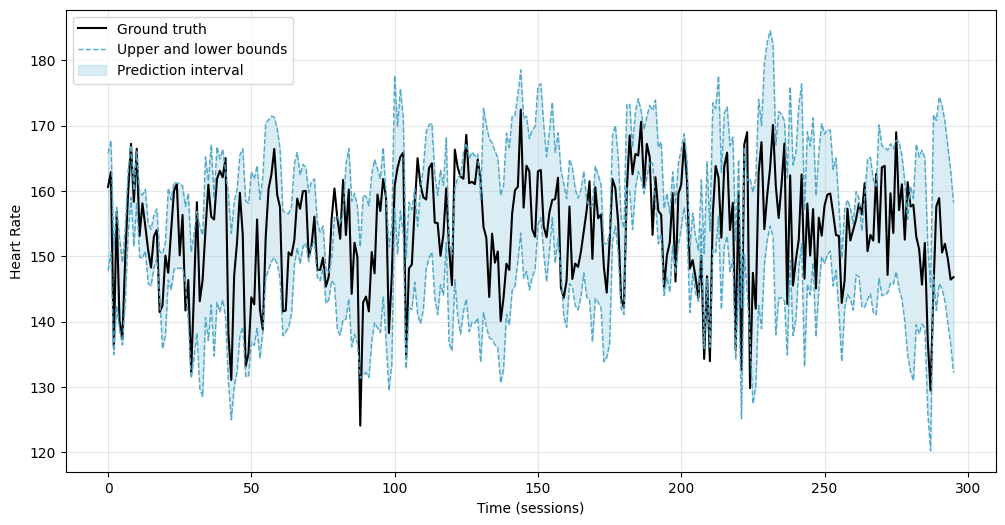

Figure saved


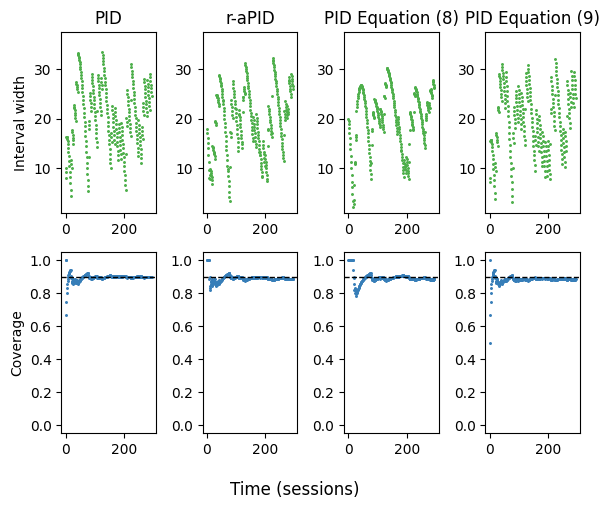

In [ ]:
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])

method_params = {"PID_log":{"l_r":4,"q":5,"v":None},"PID_log_half_smooth_bis":{"l_r":4,"q":9,"v":np.array([6])},
                 "PID_log_full_smooth":{"l_r":2,"q":10,"v":np.array([16])},"PID_log_half_smooth":{"l_r":4,"q":4,"v":np.array([11])}}
name_methods=list(method_params.keys())
method_to_title={"PID_log":"PID","PID_log_half_smooth_bis":"r-aPID","PID_log_half_smooth":'PID Equation (9)',"PID_log_full_smooth":"PID Equation (8)"}

player='MHSC-18'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search,cv_method,n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,t_burnin=30,q1=params["q"],lr=params["l_r"],Csat=5,KI=10,f=f_w_v(w,params['v'],alpha))
    results[method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[method],"width_mean":mean_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width})
    print(cov,mean_width,median_width)
title=f'exp1_{dataset}_{player}_{basemodel}'
title_interval=f'exp1_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["PID_log_half_smooth_bis"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-51

0.889795918367347 21.12708648804332 20.744292476816156
0.8857142857142857 21.09932601918125 20.534439101288058
0.8857142857142857 20.879940376814734 19.992649903177607
0.889795918367347 20.557608490339543 19.10221379105235
Figure saved


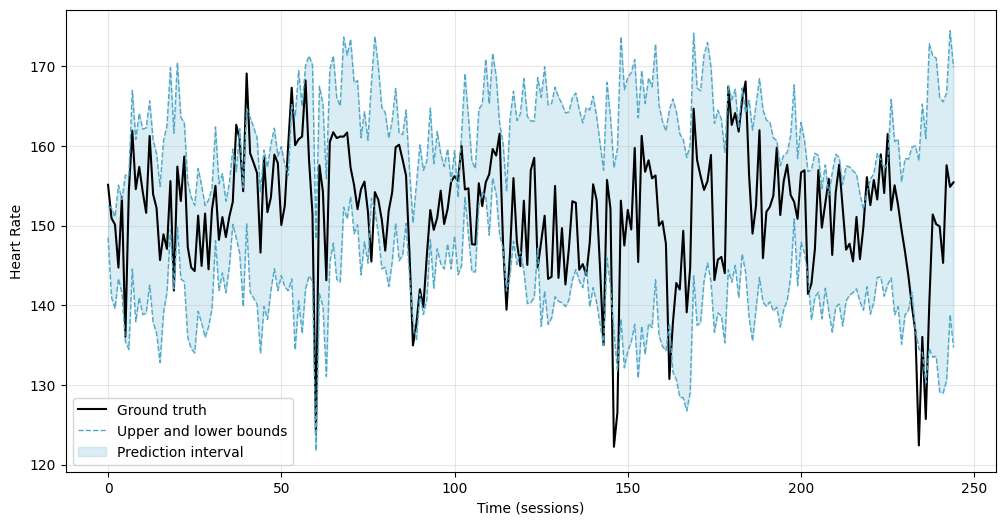

Figure saved


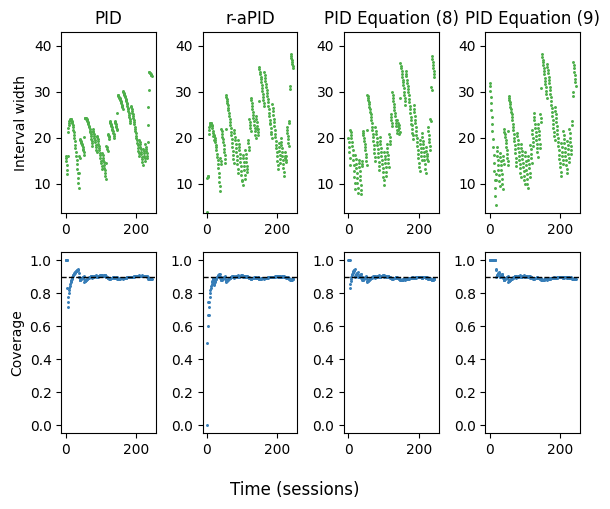

In [ ]:
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])

method_params = {"PID_log":{"l_r":2,"q":8,"v":None},"PID_log_half_smooth_bis":{"l_r":4,"q":2,"v":np.array([11])},
                 "PID_log_full_smooth":{"l_r":4,"q":10,"v":np.array([15])},"PID_log_half_smooth":{"l_r":4,"q":16,"v":np.array([9])}}
name_methods=list(method_params.keys())
method_to_title={"PID_log":"PID","PID_log_half_smooth_bis":"r-aPID","PID_log_half_smooth":'PID Equation (9)',"PID_log_full_smooth":"PID Equation (8)"}

player='MHSC-51'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search,cv_method,n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,t_burnin=30,q1=params["q"],lr=params["l_r"],Csat=5,KI=10,f=f_w_v(w,params['v'],alpha))
    results[method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[method],"width_mean":mean_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width})
    print(cov,mean_width,median_width)
title=f'exp1_{dataset}_{player}_{basemodel}'
title_interval=f'exp1_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["PID_log_half_smooth_bis"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-71

0.8888888888888888 16.700708890683106 17.596733879590715
0.8888888888888888 16.41574312558133 16.407289549470192
0.898989898989899 16.64737620373433 16.761019115544002
0.898989898989899 16.764368497993672 16.585729201883964
Figure saved


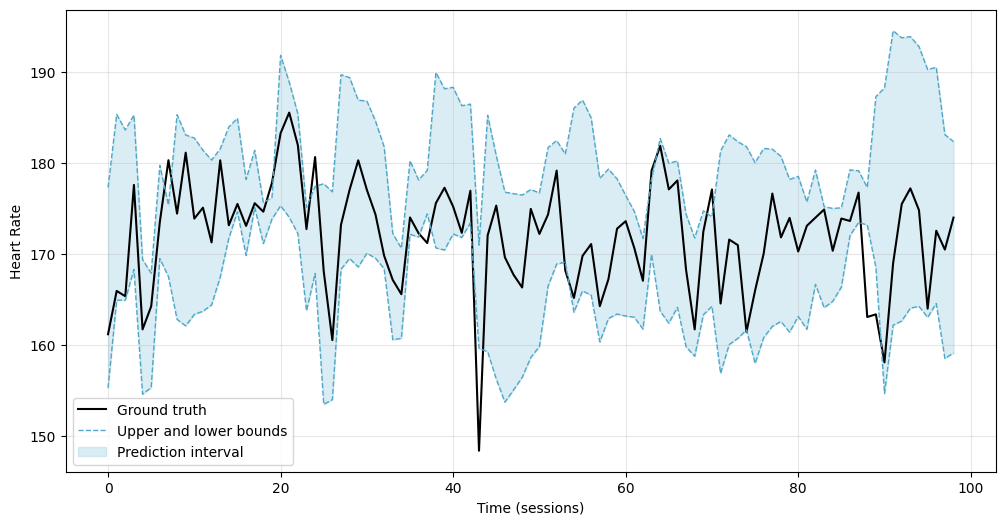

Figure saved


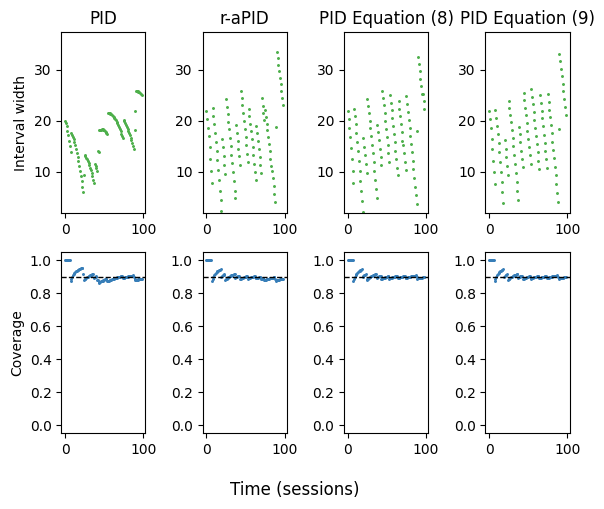

In [ ]:
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])

method_params = {"PID_log":{"l_r":2,"q":10,"v":None},"PID_log_half_smooth_bis":{"l_r":8,"q":11,"v":np.array([14])},
                 "PID_log_full_smooth":{"l_r":8,"q":11,"v":np.array([20])},"PID_log_half_smooth":{"l_r":8,"q":11,"v":np.array([20])}}
name_methods=list(method_params.keys())
method_to_title={"PID_log":"PID","PID_log_half_smooth_bis":"r-aPID","PID_log_half_smooth":'PID Equation (9)',"PID_log_full_smooth":"PID Equation (8)"}

player='MHSC-71'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search,cv_method,n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,t_burnin=30,q1=params["q"],lr=params["l_r"],Csat=5,KI=10,f=f_w_v(w,params['v'],alpha))
    results[method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[method],"width_mean":mean_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width})
    print(cov,mean_width,median_width)
title=f'exp1_{dataset}_{player}_{basemodel}'
title_interval=f'exp1_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["PID_log_half_smooth_bis"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-75

0.8942307692307693 21.08760499331955 20.917874440512094
0.8942307692307693 20.476568060225418 20.60420558717908
0.8942307692307693 19.50074855863429 20.700197597419162
0.8942307692307693 19.938065843292275 21.062403530700493
Figure saved


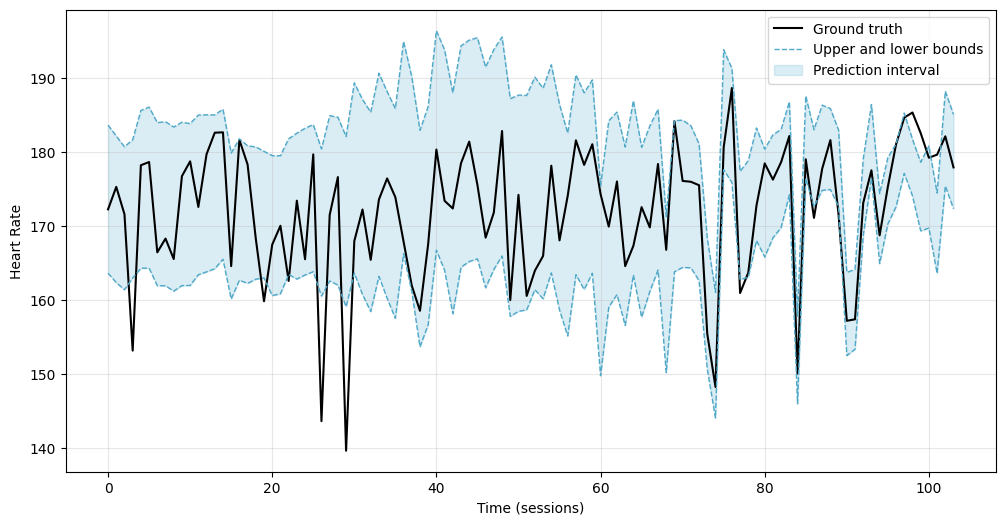

Figure saved


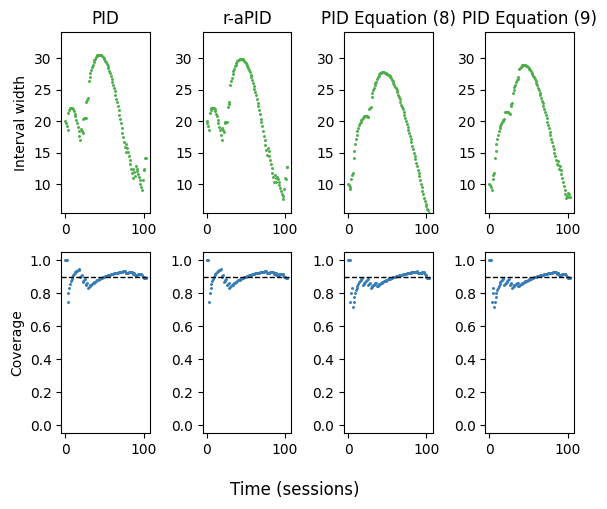

In [ ]:
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])

method_params = {"PID_log":{"l_r":1,"q":10,"v":None},"PID_log_half_smooth_bis":{"l_r":1,"q":10,"v":np.array([14])},
                 "PID_log_full_smooth":{"l_r":0.5,"q":5,"v":np.array([1])},"PID_log_half_smooth":{"l_r":0.5,"q":5,"v":np.array([1])}}
name_methods=list(method_params.keys())
method_to_title={"PID_log":"PID","PID_log_half_smooth_bis":"r-aPID","PID_log_half_smooth":'PID Equation (9)',"PID_log_full_smooth":"PID Equation (8)"}

player='MHSC-75'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search,cv_method,n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,t_burnin=30,q1=params["q"],lr=params["l_r"],Csat=5,KI=10,f=f_w_v(w,params['v'],alpha))
    results[method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[method],"width_mean":mean_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width})
    print(cov,mean_width,median_width)
title=f'exp1_{dataset}_{player}_{basemodel}'
title_interval=f'exp1_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["PID_log_half_smooth_bis"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-19

0.8980891719745223 20.275605890052532 19.71340404325599
0.8853503184713376 18.5350339321105 18.702229931008446
0.8853503184713376 19.095861407022632 19.31895381662423
0.8853503184713376 18.715147339354157 18.960976957287414
Figure saved


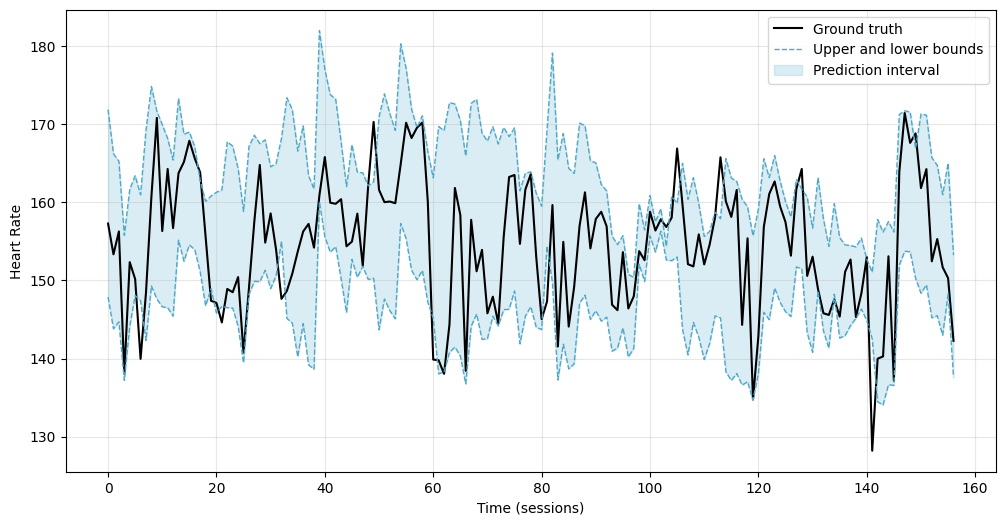

Figure saved


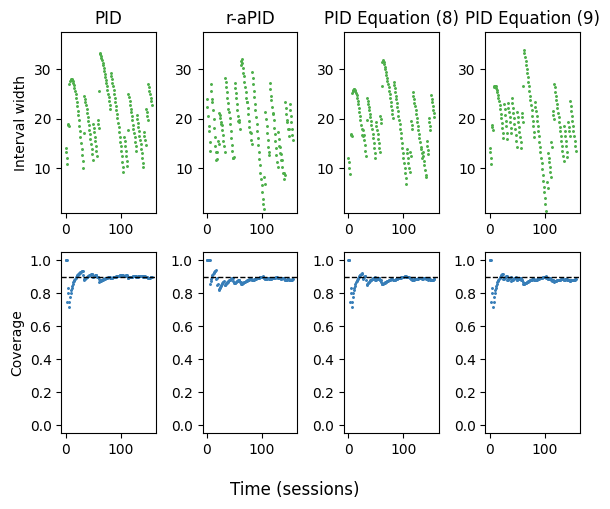

In [ ]:
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])

method_params = {"PID_log":{"l_r":4,"q":7,"v":None},"PID_log_half_smooth_bis":{"l_r":8,"q":12,"v":np.array([4])},
                 "PID_log_full_smooth":{"l_r":4,"q":6,"v":np.array([15])},"PID_log_half_smooth":{"l_r":4,"q":7,"v":np.array([6])}}
name_methods=list(method_params.keys())
method_to_title={"PID_log":"PID","PID_log_half_smooth_bis":"r-aPID","PID_log_half_smooth":'PID Equation (9)',"PID_log_full_smooth":"PID Equation (8)"}

player='MHSC-19'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search,cv_method,n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,t_burnin=30,q1=params["q"],lr=params["l_r"],Csat=5,KI=10,f=f_w_v(w,params['v'],alpha))
    results[method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[method],"width_mean":mean_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width})
    print(cov,mean_width,median_width)
title=f'exp1_{dataset}_{player}_{basemodel}'
title_interval=f'exp1_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["PID_log_half_smooth_bis"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-65

0.8983957219251337 22.889214916765393 22.92138375599285
0.8877005347593583 21.84557344557572 23.874453240146124
0.893048128342246 22.077728128656513 22.80533121973184
0.8877005347593583 21.410640752211275 21.114381256203785
Figure saved


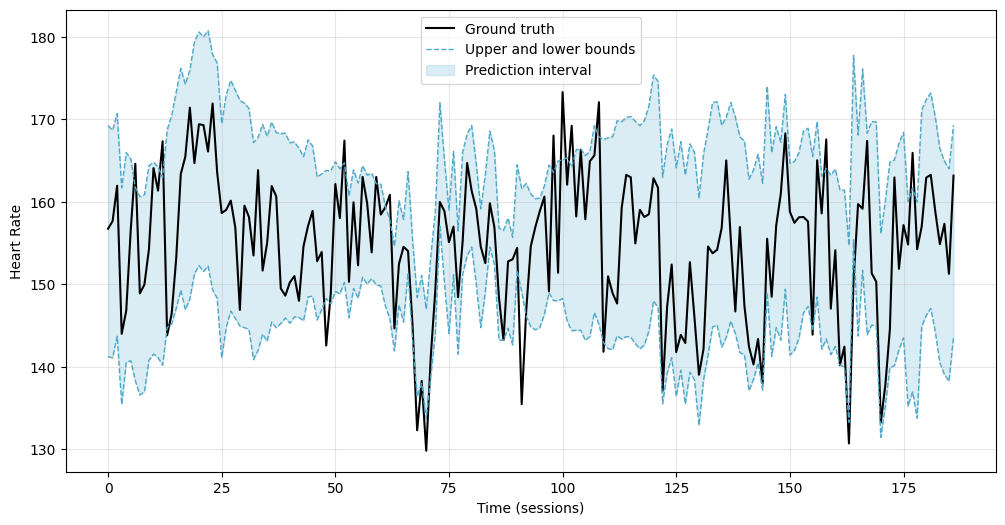

Figure saved


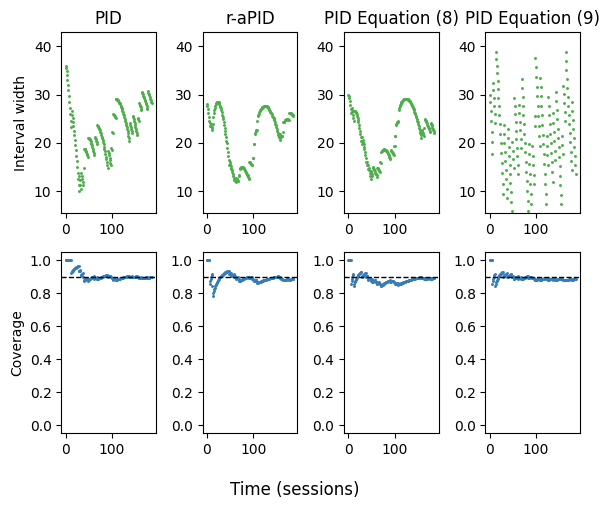

In [ ]:
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])

method_params = {"PID_log":{"l_r":2,"q":18,"v":None},"PID_log_half_smooth_bis":{"l_r":2,"q":14,"v":np.array([2])},
                 "PID_log_full_smooth":{"l_r":1,"q":15,"v":np.array([19])},"PID_log_half_smooth":{"l_r":8,"q":15,"v":np.array([7])}}
name_methods=list(method_params.keys())
method_to_title={"PID_log":"PID","PID_log_half_smooth_bis":"r-aPID","PID_log_half_smooth":'PID Equation (9)',"PID_log_full_smooth":"PID Equation (8)"}

player='MHSC-65'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search,cv_method,n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,t_burnin=30,q1=params["q"],lr=params["l_r"],Csat=5,KI=10,f=f_w_v(w,params['v'],alpha))
    results[method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[method],"width_mean":mean_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width})
    print(cov,mean_width,median_width)
title=f'exp1_{dataset}_{player}_{basemodel}'
title_interval=f'exp1_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["PID_log_half_smooth_bis"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-59

0.8903225806451613 21.586912243232508 20.873783943780722
0.8903225806451613 21.09535639901355 20.50074030579441
0.8903225806451613 20.499482579129197 17.88754200520168
0.8903225806451613 20.34726718352999 17.686506378503736
Figure saved


c:\Users\tdupuy\Documents\Thèse\Online_CP\OCP_relevance_special_issue\utils.py:295: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


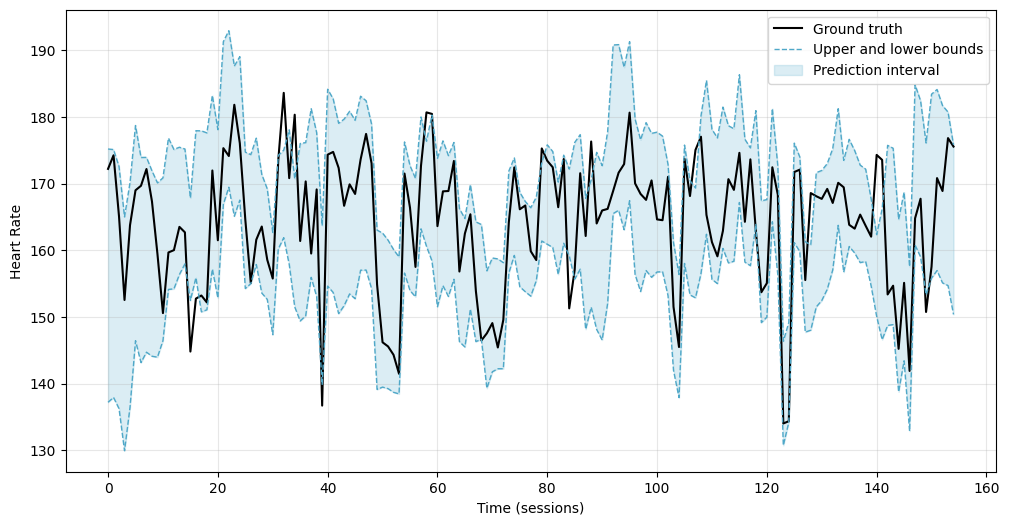

Figure saved


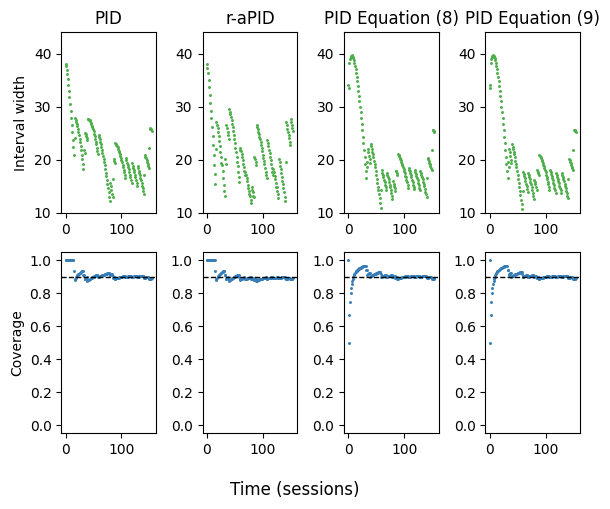

In [ ]:
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])

method_params = {"PID_log":{"l_r":2,"q":19,"v":None},"PID_log_half_smooth_bis":{"l_r":4,"q":19,"v":np.array([5])},
                 "PID_log_full_smooth":{"l_r":2,"q":17,"v":np.array([16])},"PID_log_half_smooth":{"l_r":2,"q":17,"v":np.array([14])}}
name_methods=list(method_params.keys())
method_to_title={"PID_log":"PID","PID_log_half_smooth_bis":"r-aPID","PID_log_half_smooth":'PID Equation (9)',"PID_log_full_smooth":"PID Equation (8)"}

player='MHSC-59'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search,cv_method,n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,t_burnin=30,q1=params["q"],lr=params["l_r"],Csat=5,KI=10,f=f_w_v(w,params['v'],alpha))
    results[method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[method],"width_mean":mean_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width})
    print(cov,mean_width,median_width)
title=f'exp1_{dataset}_{player}_{basemodel}'
title_interval=f'exp1_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["PID_log_half_smooth_bis"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-55

0.8971631205673759 23.720184468756358 21.67963947388796
0.8900709219858156 23.194881320639038 21.306498715711854
0.8865248226950354 22.548976262252133 23.43580532780993
0.8865248226950354 22.46333593717046 23.14132914649815
Figure saved


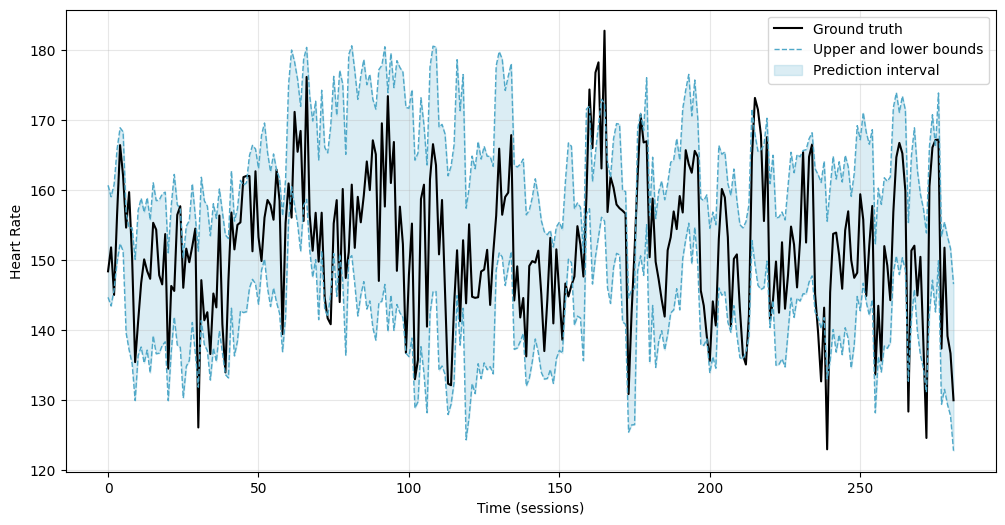

Figure saved


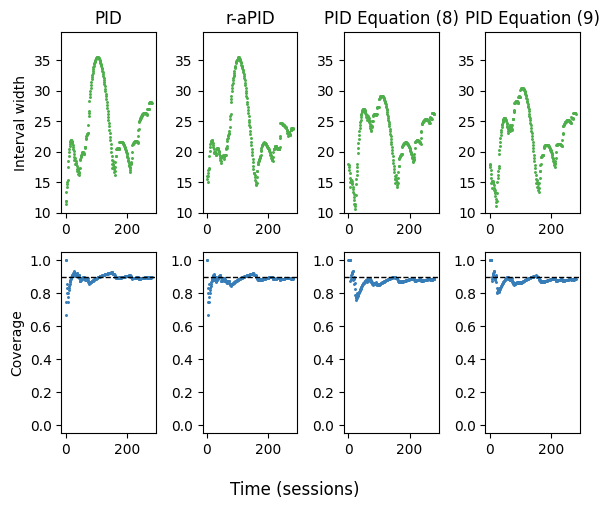

In [ ]:
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])

method_params = {"PID_log":{"l_r":0.5,"q":6,"v":None},"PID_log_half_smooth_bis":{"l_r":2,"q":8,"v":np.array([1])},
                 "PID_log_full_smooth":{"l_r":0.5,"q":9,"v":np.array([13])},"PID_log_half_smooth":{"l_r":0.5,"q":9,"v":np.array([15])}}
name_methods=list(method_params.keys())
method_to_title={"PID_log":"PID","PID_log_half_smooth_bis":"r-aPID","PID_log_half_smooth":'PID Equation (9)',"PID_log_full_smooth":"PID Equation (8)"}

player='MHSC-55'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search,cv_method,n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,t_burnin=30,q1=params["q"],lr=params["l_r"],Csat=5,KI=10,f=f_w_v(w,params['v'],alpha))
    results[method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[method],"width_mean":mean_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width})
    print(cov,mean_width,median_width)
title=f'exp1_{dataset}_{player}_{basemodel}'
title_interval=f'exp1_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["PID_log_half_smooth_bis"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-53

0.8954248366013072 24.673267899596844 24.62058439960157
0.8888888888888888 22.94123442632209 22.912752214411057
0.8888888888888888 26.54559528423809 29.771575102999805
0.8888888888888888 24.736581125004207 23.283009386482547
Figure saved


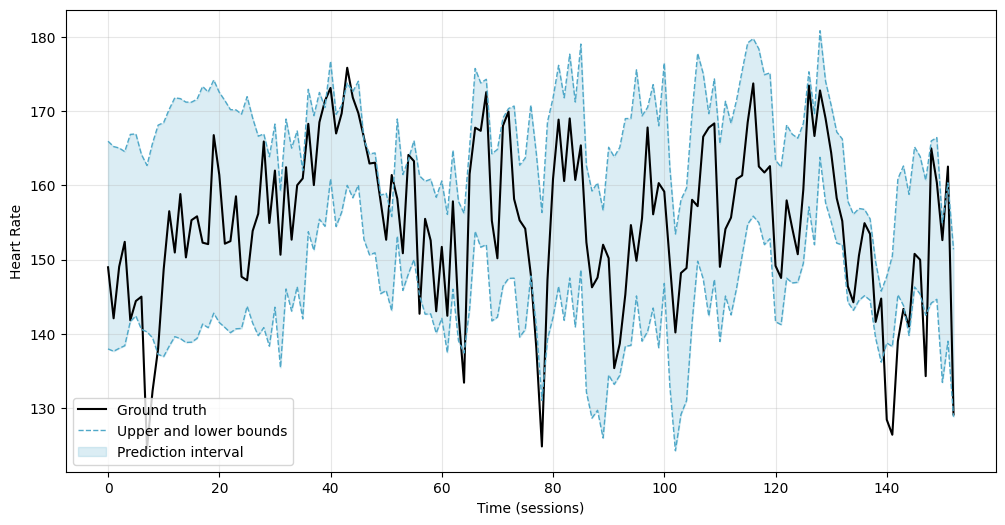

Figure saved


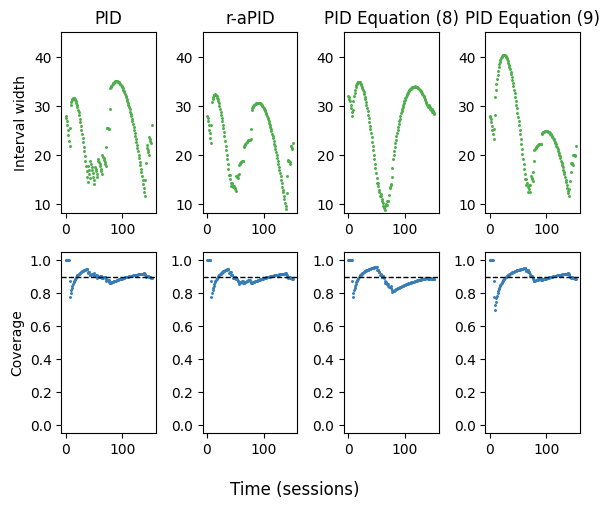

In [ ]:
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])

method_params = {"PID_log":{"l_r":2,"q":14,"v":None},"PID_log_half_smooth_bis":{"l_r":2,"q":14,"v":np.array([4])},
                 "PID_log_full_smooth":{"l_r":0.5,"q":16,"v":np.array([7])},"PID_log_half_smooth":{"l_r":1,"q":14,"v":np.array([20])}}
name_methods=list(method_params.keys())
method_to_title={"PID_log":"PID","PID_log_half_smooth_bis":"r-aPID","PID_log_half_smooth":'PID Equation (9)',"PID_log_full_smooth":"PID Equation (8)"}

player='MHSC-53'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search,cv_method,n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,t_burnin=30,q1=params["q"],lr=params["l_r"],Csat=5,KI=10,f=f_w_v(w,params['v'],alpha))
    results[method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[method],"width_mean":mean_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width})
    print(cov,mean_width,median_width)
title=f'exp1_{dataset}_{player}_{basemodel}'
title_interval=f'exp1_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["PID_log_half_smooth_bis"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-39

0.900497512437811 24.45044630403612 23.361024213653423
0.8955223880597015 22.39143030469348 20.85813699648986
0.8905472636815921 21.85982742052307 19.954338568472735
0.8905472636815921 21.66110954250291 19.362351879990115
Figure saved


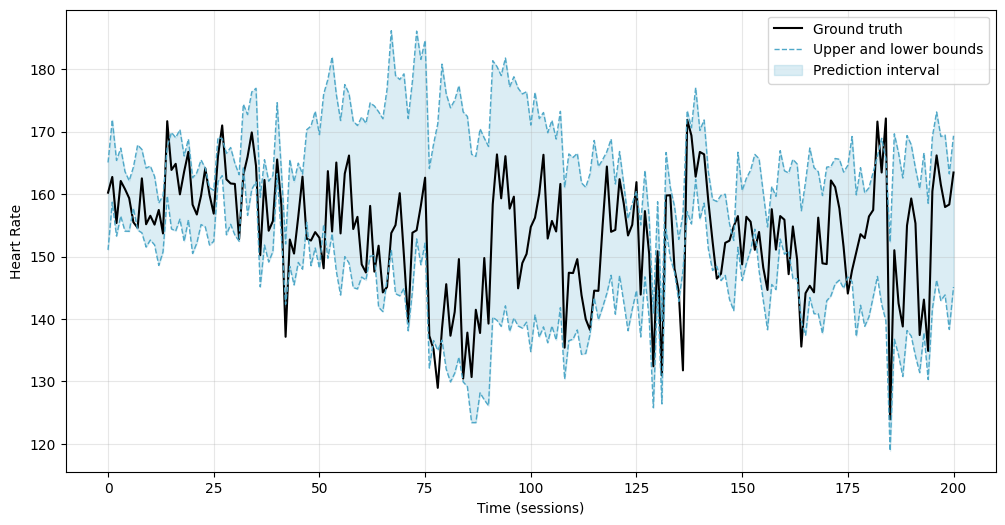

Figure saved


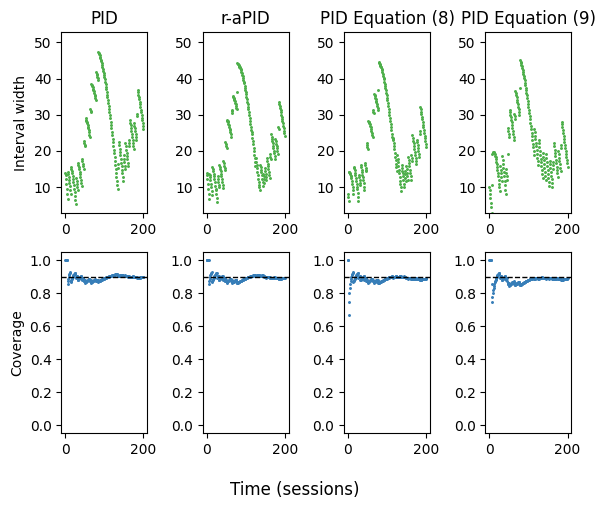

In [ ]:
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])

method_params = {"PID_log":{"l_r":4,"q":7,"v":None},"PID_log_half_smooth_bis":{"l_r":4,"q":7,"v":np.array([8])},
                 "PID_log_full_smooth":{"l_r":4,"q":4,"v":np.array([9])},"PID_log_half_smooth":{"l_r":4,"q":5,"v":np.array([11])}}
name_methods=list(method_params.keys())
method_to_title={"PID_log":"PID","PID_log_half_smooth_bis":"r-aPID","PID_log_half_smooth":'PID Equation (9)',"PID_log_full_smooth":"PID Equation (8)"}

player='MHSC-39'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search,cv_method,n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,t_burnin=30,q1=params["q"],lr=params["l_r"],Csat=5,KI=10,f=f_w_v(w,params['v'],alpha))
    results[method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[method],"width_mean":mean_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width})
    print(cov,mean_width,median_width)
title=f'exp1_{dataset}_{player}_{basemodel}'
title_interval=f'exp1_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["PID_log_half_smooth_bis"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-25

0.9028571428571428 25.35507548914002 25.21299012313628
0.8914285714285715 24.618509517948684 25.127950123475898
0.8857142857142857 24.999292791170642 25.58635478124196
0.8885714285714286 24.353056013871225 23.763146255016608
Figure saved


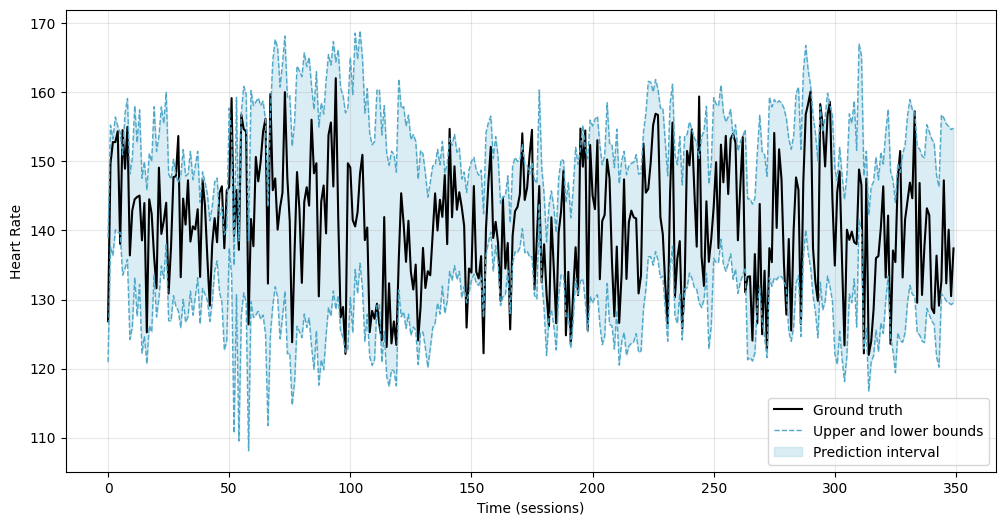

Figure saved


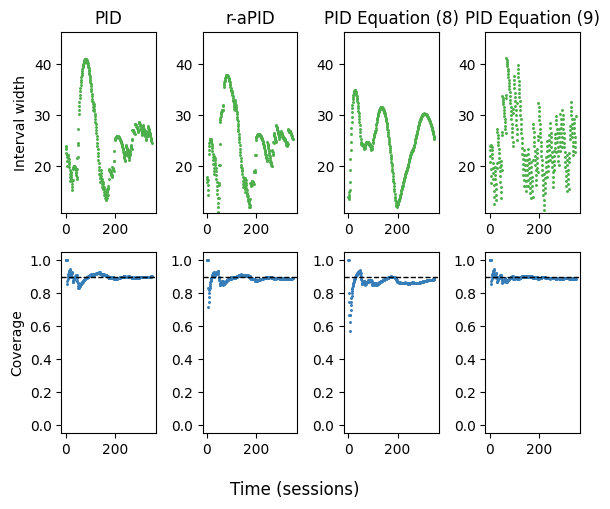

In [ ]:
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])

method_params = {"PID_log":{"l_r":1,"q":12,"v":None},"PID_log_half_smooth_bis":{"l_r":2,"q":9,"v":np.array([6])},
                 "PID_log_full_smooth":{"l_r":0.1,"q":7,"v":np.array([11])},"PID_log_half_smooth":{"l_r":4,"q":12,"v":np.array([18])}}
name_methods=list(method_params.keys())
method_to_title={"PID_log":"PID","PID_log_half_smooth_bis":"r-aPID","PID_log_half_smooth":'PID Equation (9)',"PID_log_full_smooth":"PID Equation (8)"}

player='MHSC-25'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search,cv_method,n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,t_burnin=30,q1=params["q"],lr=params["l_r"],Csat=5,KI=10,f=f_w_v(w,params['v'],alpha))
    results[method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[method],"width_mean":mean_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width})
    print(cov,mean_width,median_width)
title=f'exp1_{dataset}_{player}_{basemodel}'
title_interval=f'exp1_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["PID_log_half_smooth_bis"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-16

0.8994845360824743 24.976984755269562 25.041709868839767
0.8917525773195877 23.77987265197384 24.260398261411268
0.8865979381443299 24.82793921712126 24.900551172557186
0.8865979381443299 23.694987999294543 23.64482925546082
Figure saved


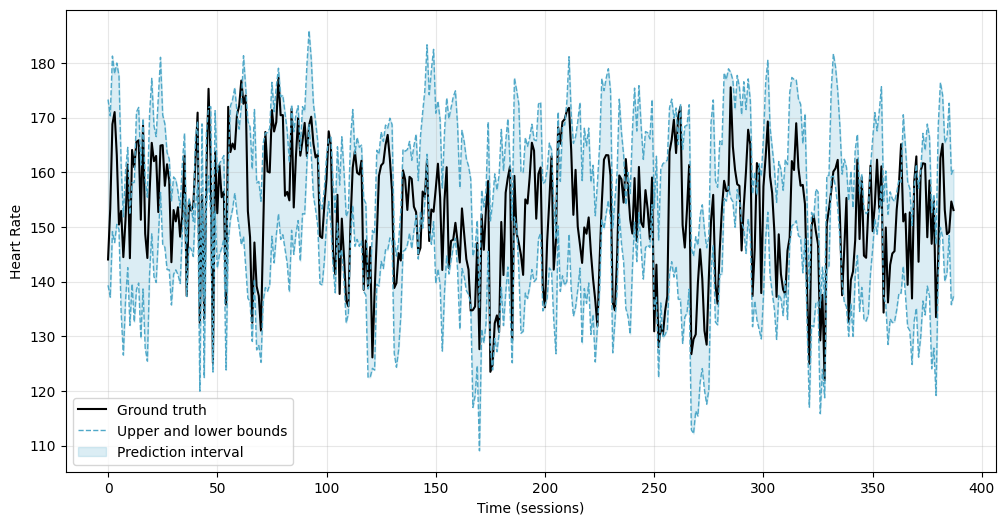

Figure saved


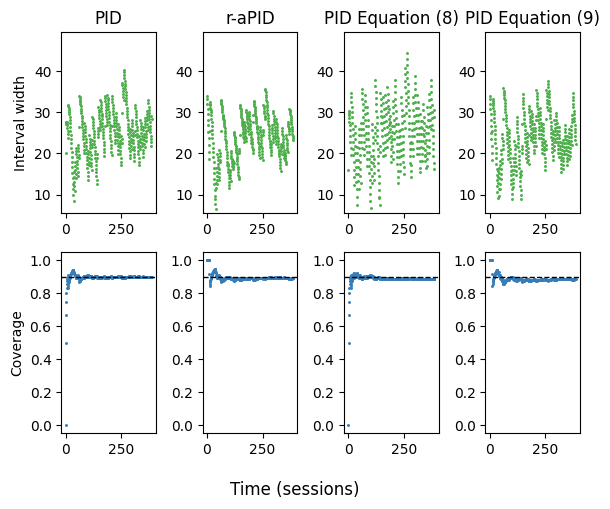

In [ ]:
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])

method_params = {"PID_log":{"l_r":4,"q":10,"v":None},"PID_log_half_smooth_bis":{"l_r":4,"q":17,"v":np.array([11])},
                 "PID_log_full_smooth":{"l_r":8,"q":8,"v":np.array([16])},"PID_log_half_smooth":{"l_r":4,"q":17,"v":np.array([10])}}
name_methods=list(method_params.keys())
method_to_title={"PID_log":"PID","PID_log_half_smooth_bis":"r-aPID","PID_log_half_smooth":'PID Equation (9)',"PID_log_full_smooth":"PID Equation (8)"}

player='MHSC-16'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search,cv_method,n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,t_burnin=30,q1=params["q"],lr=params["l_r"],Csat=5,KI=10,f=f_w_v(w,params['v'],alpha))
    results[method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[method],"width_mean":mean_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width,"width_median":median_width})
    print(cov,mean_width,median_width)
title=f'exp1_{dataset}_{player}_{basemodel}'
title_interval=f'exp1_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["PID_log_half_smooth_bis"],title_interval)
plot_exp(title,results,name_methods,method_to_title)